## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from tqdm import tqdm
import sys
import os
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.date_aligner import align_to_trading_day
from src.sentiment_classifier import classify_sentiment

## Load news data

In [2]:
news_df = load_data('../data/raw/raw_analyst_ratings.csv')

✅ Loaded: raw_analyst_ratings.csv
   Shape: (1407328, 6) rows × 6 columns
   Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


## Convert news date to datetime

In [3]:
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)

## Remove rows with invalid dates

In [4]:
initial_len = len(news_df)
news_df = news_df.dropna(subset=['date'])
print(f"\n✅ Converted news dates: {initial_len - len(news_df)} rows removed")


✅ Converted news dates: 0 rows removed


## Extract date only (without time) for initial matching

In [5]:
news_df['date_only'] = news_df['date'].dt.date
news_df['hour'] = news_df['date'].dt.hour

print(f"\n📅 News Date Range: {news_df['date'].min()} to {news_df['date'].max()}")
print(f"   Total news articles: {len(news_df):,}")


📅 News Date Range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
   Total news articles: 1,407,328


## LOAD STOCK DATA

In [6]:
stock_ticker = "META" 
stock_file = f'../data/raw/{stock_ticker}.csv'  # Adjust path

try:
    stock_df = load_data(stock_file)
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])
    stock_df = stock_df.sort_values('Date').reset_index(drop=True)
    print(f"   Date range: {stock_df['Date'].min().date()} to {stock_df['Date'].max().date()}")
except FileNotFoundError:
    print(f"\n⚠️ Stock file not found: {stock_file}")
    print("   Creating sample trading calendar for demonstration...")
    
    # Create trading calendar if stock data not available
    trading_days = pd.date_range(
        start=news_df['date'].min().date(),
        end=news_df['date'].max().date(),
        freq='B'  # Business days only (excludes weekends)
    )
    stock_df = pd.DataFrame({'Date': trading_days})
    print(f"   Created trading calendar: {len(stock_df)} trading days")

# Create a set of trading dates for quick lookup
trading_dates = set(stock_df['Date'].dt.date)

print(f"\n📊 Trading Calendar:")
print(f"   Total trading days: {len(trading_dates)}")
print(f"   First trading day: {min(trading_dates)}")
print(f"   Last trading day: {max(trading_dates)}")

✅ Loaded: META.csv
   Shape: (2923, 6) rows × 6 columns
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
   Date range: 2012-05-18 to 2023-12-29

📊 Trading Calendar:
   Total trading days: 2923
   First trading day: 2012-05-18
   Last trading day: 2023-12-29


## ALIGN NEWS TO TRADING DAYS

In [7]:
# Get the first and last trading day for the stock
first_trading_day = stock_df['Date'].min()
last_trading_day = stock_df['Date'].max()

# Remove timezone from news dates to match stock dates
news_df['date'] = news_df['date'].dt.tz_localize(None)

# Now filter news to only dates within trading range
initial_count = len(news_df)
news_df = news_df[(news_df['date'] >= first_trading_day) & (news_df['date'] <= last_trading_day)]
print(f"   Filtered news to trading range: {initial_count - len(news_df):,} rows removed")

# Now align
news_df['trading_date'] = news_df['date'].apply(
    lambda x: align_to_trading_day(x, trading_dates)
)

# Check alignment results
aligned_count = news_df['trading_date'].notna().sum()
unaligned_count = len(news_df) - aligned_count

print(f"\n📊 Alignment Results:")
print(f"   Successfully aligned: {aligned_count:,} ({aligned_count/len(news_df)*100:.1f}%)")
print(f"   Unaligned: {unaligned_count:,} ({unaligned_count/len(news_df)*100:.1f}%)")

   Filtered news to trading range: 274,909 rows removed

📊 Alignment Results:
   Successfully aligned: 1,132,419 (100.0%)
   Unaligned: 0 (0.0%)


## ANALYZE ALIGNMENT PATTERNS

In [8]:
# How many articles were published on weekends?
news_df['day_of_week'] = news_df['date'].dt.dayofweek
weekend_mask = news_df['day_of_week'].isin([5, 6])  # Saturday=5, Sunday=6
weekend_articles = weekend_mask.sum()

print(f"\n📅 Publication Day Analysis:")
print(f"   Weekend articles: {weekend_articles:,} ({weekend_articles/len(news_df)*100:.1f}%)")
print(f"   Weekday articles: {len(news_df)-weekend_articles:,}")

# Show examples of aligned dates
print(f"\n📋 Examples of date alignment:")
print("-" * 70)
examples = news_df[['date', 'trading_date', 'day_of_week']].head(10)
for _, row in examples.iterrows():
    original = row['date'].strftime('%Y-%m-%d %H:%M')
    aligned = row['trading_date'].strftime('%Y-%m-%d')
    is_weekend = "Weekend" if row['day_of_week'] >= 5 else "Weekday"
    print(f"   Original: {original:<22} → Aligned: {aligned:<12} ({is_weekend})")

# Count articles per trading day
articles_per_day = news_df.groupby('trading_date').size().sort_values(ascending=False)
print(f"\n📊 Articles per Trading Day:")
print(f"   Average: {articles_per_day.mean():.1f} articles/day")
print(f"   Max: {articles_per_day.max()} articles/day")
print(f"   Days with >100 articles: {(articles_per_day > 100).sum()}")


📅 Publication Day Analysis:
   Weekend articles: 18,307 (1.6%)
   Weekday articles: 1,114,112

📋 Examples of date alignment:
----------------------------------------------------------------------
   Original: 2020-06-05 14:30       → Aligned: 2020-06-05   (Weekday)
   Original: 2020-06-03 14:45       → Aligned: 2020-06-03   (Weekday)
   Original: 2020-05-26 08:30       → Aligned: 2020-05-26   (Weekday)
   Original: 2020-05-22 16:45       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 15:38       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 15:23       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 13:36       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 13:07       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 12:37       → Aligned: 2020-05-22   (Weekday)
   Original: 2020-05-22 12:06       → Aligned: 2020-05-22   (Weekday)

📊 Articles per Trading Day:
   Average: 558.1 articles/day
   Max: 2739 articles/day
   Days with >100

In [ ]:
print(f"   Unique stocks: {news_df['stock'].nunique()}")
print(f"   Top 10 stocks by article count:")
print(news_df['stock'].value_counts().head(10))

# Filter for specific stock
if 'FB' in news_df['stock'].values:
    stock_news = news_df[news_df['stock'] == 'FB'].copy()
    print(f"\n✅ Filtered news for {'FB'}: {len(stock_news)} articles")
else:
    print(f"\n⚠️ No news found for {'FB'}")
    stock_news = news_df.copy()
    print(f"   Using all news for analysis")

   Unique stocks: 6126
   Top 10 stocks by article count:
stock
NFLX    3028
VZ      2920
BABA    2858
NVDA    2854
MU      2849
EBAY    2820
QCOM    2788
MRK     2678
JNJ     2660
BBRY    2578
Name: count, dtype: int64

✅ Filtered news for FB: 380 articles


## Sentiment Analysis using NLTK VADER

In [ ]:
# Download VADER lexicon (run once)
nltk.download('vader_lexicon', quiet=True)

In [12]:
# Apply VADER to every headline and store the compound score
sia = SentimentIntensityAnalyzer()

# vader_compound is a number from -1.0 (very negative) to +1.0 (very positive)
stock_news['vader_compound'] = stock_news['headline'].apply(
    lambda text: sia.polarity_scores(str(text))['compound']
)

# Classify each score into a label using the standard VADER thresholds
stock_news['sentiment'] = stock_news['vader_compound'].apply(classify_sentiment)

# Show a few examples to build intuition
print("VADER SENTIMENT ANALYSIS RESULTS")

print('\n📊 Examples — Highest scoring headlines (most positive):')
print(stock_news.nlargest(3, 'vader_compound')[['headline', 'stock', 'vader_compound', 'sentiment']].to_string(index=False))

print('\n📊 Examples — Lowest scoring headlines (most negative):')
print(stock_news.nsmallest(3, 'vader_compound')[['headline', 'stock', 'vader_compound', 'sentiment']].to_string(index=False))

# Summary statistics
print(f"\n📊 Sentiment Distribution:")
print(stock_news['sentiment'].value_counts())
print(f"\n📊 Mean VADER score: {stock_news['vader_compound'].mean():.4f}")

VADER SENTIMENT ANALYSIS RESULTS

📊 Examples — Highest scoring headlines (most positive):
                                                                                                                                                                                                                                       headline stock  vader_compound sentiment
UPDATE: Mizuho On Facebook Notes 'In addition, underlying usage was strong, especially for video streaming like FB Live and Watch, and Mobile Messaging, which are strategically positive, supporting our LT thesis for under-monetized assets'    FB          0.9186  Positive
                                                                                                                  Shares of several communication services companies are trading higher as equities gain amid hopes of a US stimulus agreement.    FB          0.8910  Positive
                                             Shares of several social media and internet commu

## CALCULATE DAILY STOCK RETURNS

In [14]:
# Calculate daily returns
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

print(f"\n✅ Daily returns calculated for {stock_ticker}")
print(f"   Date range: {stock_df['Date'].min().date()} to {stock_df['Date'].max().date()}")
print(f"   Total trading days: {len(stock_df):,}")

# Display sample
print("\n📋 Sample of daily returns:")
print("-" * 60)
sample_returns = stock_df[['Date', 'Close', 'daily_return']].head(10)
for idx, row in sample_returns.iterrows():
    print(f"   {row['Date'].date()}: Close=${row['Close']:.2f}, Return={row['daily_return']:.2f}%")

# Summary statistics
print(f"\n📊 Daily Return Statistics (%):")
print(f"   Mean daily return: {stock_df['daily_return'].mean():.4f}%")
print(f"   Median daily return: {stock_df['daily_return'].median():.4f}%")
print(f"   Std deviation: {stock_df['daily_return'].std():.4f}%")
print(f"   Best day: {stock_df['daily_return'].max():.2f}%")
print(f"   Worst day: {stock_df['daily_return'].min():.2f}%")


✅ Daily returns calculated for META
   Date range: 2012-05-18 to 2023-12-29
   Total trading days: 2,923

📋 Sample of daily returns:
------------------------------------------------------------
   2012-05-18: Close=$38.00, Return=nan%
   2012-05-21: Close=$33.82, Return=-10.99%
   2012-05-22: Close=$30.81, Return=-8.90%
   2012-05-23: Close=$31.80, Return=3.23%
   2012-05-24: Close=$32.83, Return=3.22%
   2012-05-25: Close=$31.71, Return=-3.39%
   2012-05-29: Close=$28.66, Return=-9.62%
   2012-05-30: Close=$28.02, Return=-2.25%
   2012-05-31: Close=$29.42, Return=5.00%
   2012-06-01: Close=$27.55, Return=-6.35%

📊 Daily Return Statistics (%):
   Mean daily return: 0.1082%
   Median daily return: 0.0998%
   Std deviation: 2.5280%
   Best day: 29.61%
   Worst day: -26.39%


## Aggregate daily sentiment

In [15]:
# Group by trading_date and calculate average sentiment
daily_sentiment = stock_news.groupby('trading_date').agg({
    'vader_compound': 'mean',  # Average sentiment per day
    'headline': 'count'         # Number of articles per day
}).rename(columns={'vader_compound': 'avg_daily_sentiment', 'headline': 'article_count'})

# Reset index to make trading_date a column
daily_sentiment = daily_sentiment.reset_index()
daily_sentiment['trading_date'] = pd.to_datetime(daily_sentiment['trading_date'])

print(f"✅ Aggregated {len(daily_sentiment)} trading days with sentiment data")
print(f"\n📋 Sample of daily aggregated sentiment:")
print(daily_sentiment.head(10))

✅ Aggregated 74 trading days with sentiment data

📋 Sample of daily aggregated sentiment:
  trading_date  avg_daily_sentiment  article_count
0   2020-02-19             0.190900              2
1   2020-02-20             0.328600              2
2   2020-02-21             0.021000              4
3   2020-02-24             0.041460              5
4   2020-02-25             0.223433              3
5   2020-02-26             0.000000              2
6   2020-02-27            -0.166500              3
7   2020-02-28             0.044033              6
8   2020-03-02             0.194250              4
9   2020-03-03             0.000000              1


## Calculate Pearson correlation coefficient

In [16]:
# Merge with stock returns
# Ensure stock_df has Date column and daily_return
merged = stock_df.merge(
    daily_sentiment, 
    left_on='Date', 
    right_on='trading_date', 
    how='inner'
)

print(f"✅ Merged data: {len(merged)} common trading days")

# Calculate Pearson correlation
correlation, p_value = pearsonr(merged['avg_daily_sentiment'], merged['daily_return'])

print(f"\n📊 Pearson Correlation Results:")
print(f"   Correlation coefficient: {correlation:.4f}")
print(f"   P-value: {p_value:.4e}")

# Interpretation
if abs(correlation) < 0.2:
    strength = "Very weak"
elif abs(correlation) < 0.4:
    strength = "Weak"
elif abs(correlation) < 0.6:
    strength = "Moderate"
elif abs(correlation) < 0.8:
    strength = "Strong"
else:
    strength = "Very strong"

direction = "positive" if correlation > 0 else "negative"
print(f"   Interpretation: {strength} {direction} correlation")

if p_value < 0.05:
    print(f"   Statistically significant (p < 0.05)")
else:
    print(f"   Not statistically significant (p >= 0.05)")

✅ Merged data: 74 common trading days

📊 Pearson Correlation Results:
   Correlation coefficient: 0.4316
   P-value: 1.2355e-04
   Interpretation: Moderate positive correlation
   Statistically significant (p < 0.05)


## Scatter plot with correlation annotation

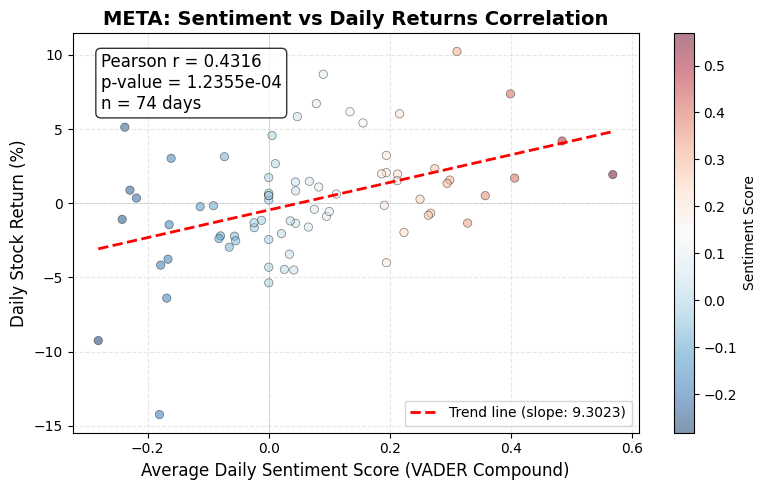

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot
scatter = ax.scatter(
    merged['avg_daily_sentiment'], 
    merged['daily_return'],
    alpha=0.5,
    c=merged['avg_daily_sentiment'],
    cmap='RdBu_r',
    edgecolors='black',
    linewidth=0.5
)

# Add trend line
z = np.polyfit(merged['avg_daily_sentiment'], merged['daily_return'], 1)
p = np.poly1d(z)
ax.plot(
    merged['avg_daily_sentiment'].sort_values(),
    p(merged['avg_daily_sentiment'].sort_values()),
    color='red',
    linewidth=2,
    linestyle='--',
    label=f'Trend line (slope: {z[0]:.4f})'
)

# Annotate correlation value
ax.annotate(
    f'Pearson r = {correlation:.4f}\np-value = {p_value:.4e}\nn = {len(merged)} days',
    xy=(0.05, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Labels and title
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)
ax.set_xlabel('Average Daily Sentiment Score (VADER Compound)', fontsize=12)
ax.set_ylabel('Daily Stock Return (%)', fontsize=12)
ax.set_title(f'{stock_ticker}: Sentiment vs Daily Returns Correlation', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Sentiment Score', fontsize=10)

plt.tight_layout()
plt.show()

## Classifying days by sentiment category


📋 Average Daily Return by Sentiment Category:
Sentiment Category  Avg Daily Return (%)  Std Dev  Number of Days
          Negative             -2.135071 4.442504              19
           Neutral             -0.647310 2.914089              22
          Positive              2.001580 3.264812              33


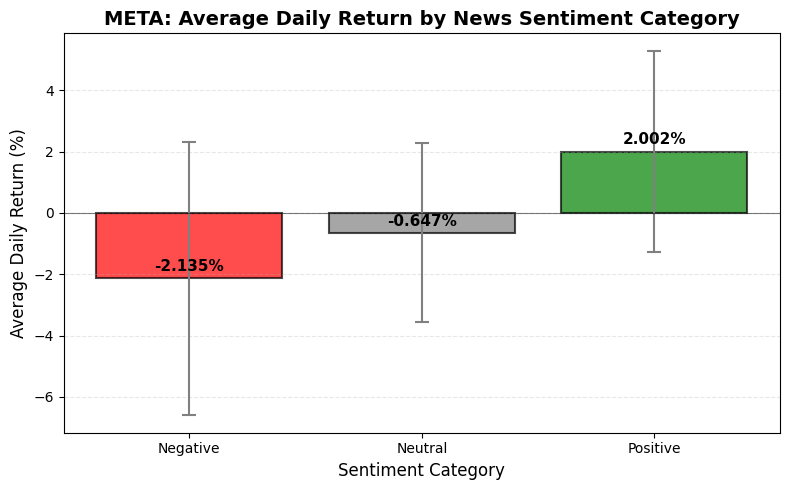

In [18]:
# Classify each day based on average sentiment score
merged['daily_sentiment_category'] = merged['avg_daily_sentiment'].apply(classify_sentiment)

# Calculate average daily return per category
category_returns = merged.groupby('daily_sentiment_category')['daily_return'].agg(['mean', 'std', 'count']).reset_index()
category_returns.columns = ['Sentiment Category', 'Avg Daily Return (%)', 'Std Dev', 'Number of Days']

print(f"\n📋 Average Daily Return by Sentiment Category:")
print(category_returns.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))

# Define colors for bars
colors_bar = {'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'}
bar_colors = [colors_bar[cat] for cat in category_returns['Sentiment Category']]

# Create bar chart
bars = ax.bar(
    category_returns['Sentiment Category'],
    category_returns['Avg Daily Return (%)'],
    color=bar_colors,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.7
)

# Add error bars (standard deviation)
ax.errorbar(
    category_returns['Sentiment Category'],
    category_returns['Avg Daily Return (%)'],
    yerr=category_returns['Std Dev'],
    fmt='none',
    color='black',
    capsize=5,
    capthick=1.5,
    ecolor='gray'
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.3f}%',
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Add horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.8)

# Labels and title
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Average Daily Return (%)', fontsize=12)
ax.set_title(f'{stock_ticker}: Average Daily Return by News Sentiment Category', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

## Interpretation

In [19]:
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS SUMMARY")
print("=" * 80)

print(f"""
Stock: {stock_ticker}
├── Trading days with news: {len(daily_sentiment)}
├── Common days with returns: {len(merged)}
├── Pearson correlation: {correlation:.4f}
├── P-value: {p_value:.4e}
└── Conclusion: {strength} {direction} correlation {'(statistically significant)' if p_value < 0.05 else '(not statistically significant)'}

Average Returns by Sentiment:
├── Positive sentiment days: {category_returns[category_returns['Sentiment Category'] == 'Positive']['Number of Days'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Positive']) > 0 else 0} days, avg return: {category_returns[category_returns['Sentiment Category'] == 'Positive']['Avg Daily Return (%)'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Positive']) > 0 else 0:.3f}%
├── Neutral sentiment days: {category_returns[category_returns['Sentiment Category'] == 'Neutral']['Number of Days'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Neutral']) > 0 else 0} days, avg return: {category_returns[category_returns['Sentiment Category'] == 'Neutral']['Avg Daily Return (%)'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Neutral']) > 0 else 0:.3f}%
└── Negative sentiment days: {category_returns[category_returns['Sentiment Category'] == 'Negative']['Number of Days'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Negative']) > 0 else 0} days, avg return: {category_returns[category_returns['Sentiment Category'] == 'Negative']['Avg Daily Return (%)'].values[0] if len(category_returns[category_returns['Sentiment Category'] == 'Negative']) > 0 else 0:.3f}%
""")


CORRELATION ANALYSIS SUMMARY

Stock: META
├── Trading days with news: 74
├── Common days with returns: 74
├── Pearson correlation: 0.4316
├── P-value: 1.2355e-04
└── Conclusion: Moderate positive correlation (statistically significant)

Average Returns by Sentiment:
├── Positive sentiment days: 33 days, avg return: 2.002%
├── Neutral sentiment days: 22 days, avg return: -0.647%
└── Negative sentiment days: 19 days, avg return: -2.135%

